# <u>**Trabajo Práctico N°1 - Parte 1 "Procesos"**</u>

<u>Materia</u>: Programación Concurrente<br>
<u>Profesores</u>: Carnuccio Esteban, Hirschfeldt Dario, Palomo Maximo Facundo, Volker Mariano Leonardo<br>
<u>Grupo</u>: M4<br>
<u>Ciclo Lectivo</u>: 1er Cuatrimestre del 2026<br>
<u>Fecha</u>: 01/05/2026

## **1.  Árbol de procesos en ANSI C<br>**
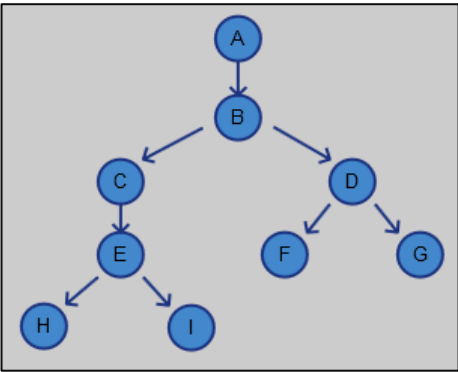

In [ ]:
%%writefile ejercicio1.c
#include <stdlib.h>
#include <stdio.h>
#include <unistd.h>
#include <sys/wait.h>

typedef struct Node
{
    char name;
    struct Node *first_child;
    struct Node *next_sibling;
} Node;

void processMessage(Node *node);
Node *create_node(char name);
void add_child(Node *parent, Node *child);
Node *create_tree();
int print_tree(Node *node);

int main(int argc, char *argv[])
{
    setbuf(stdout, NULL);
    Node *root_node = create_tree();
    return print_tree(root_node);
}

void processMessage(Node *node)
{
    printf("Hola mi nombre es %c | PID: %d | P_PID: %d\n", node->name, getpid(), getppid());
}

Node *create_node(char name) {
    Node *n = malloc(sizeof(Node));

    n->name = name;
    n->first_child = NULL;
    n->next_sibling = NULL;

    return n;
}

void add_child(Node *parent, Node *child) {
    if (!parent->first_child) {
        parent->first_child = child;
    } else {
        Node *current = parent->first_child;

        while (current->next_sibling) {
            current = current->next_sibling;
        }

        current->next_sibling = child;
    }
}

Node *create_tree() {
    Node *node_a = create_node('A');
    Node *node_b = create_node('B');
    Node *node_c = create_node('C');
    Node *node_d = create_node('D');
    Node *node_e = create_node('E');
    Node *node_f = create_node('F');
    Node *node_g = create_node('G');
    Node *node_h = create_node('H');
    Node *node_i = create_node('I');

    add_child(node_a, node_b);
    add_child(node_b, node_c);
    add_child(node_b, node_d);
    add_child(node_c, node_e);
    add_child(node_d, node_f);
    add_child(node_d, node_g);
    add_child(node_e, node_h);
    add_child(node_e, node_i);

    return node_a;
}

int print_tree(Node *node) {
    if (!node) return EXIT_SUCCESS;

    processMessage(node);

    Node *child = node->first_child;
    int pid = 0;

    while (child)
    {
      pid = fork();

      if (pid == -1)
      {
          perror("fork");
          exit(EXIT_FAILURE);
      }
      else if(pid == 0)
      {
          print_tree(child);
          sleep(50);
          return EXIT_SUCCESS;
      }
      child = child->next_sibling;
    }

    child = node->first_child;
    while (child)
    {
        wait(NULL);
        child = child->next_sibling;
    }

    return EXIT_SUCCESS;
}

Overwriting ejercicio1.c


In [ ]:
!gcc -o ejercicio1_out ejercicio1.c

In [ ]:
!nohup ./ejercicio1_out > resultado 2>/dev/null &

In [ ]:
!cat resultado

Hola mi nombre es A | PID: 14717 | P_PID: 1
Hola mi nombre es B | PID: 14718 | P_PID: 14717
Hola mi nombre es C | PID: 14719 | P_PID: 14718
Hola mi nombre es D | PID: 14720 | P_PID: 14718
Hola mi nombre es E | PID: 14721 | P_PID: 14719
Hola mi nombre es F | PID: 14722 | P_PID: 14720
Hola mi nombre es H | PID: 14724 | P_PID: 14721
Hola mi nombre es G | PID: 14723 | P_PID: 14720
Hola mi nombre es I | PID: 14725 | P_PID: 14721


In [ ]:
!ps -ef | grep ejercicio1_out

root       14717       1  0 16:53 ?        00:00:00 ./ejercicio1_out
root       14718   14717  0 16:53 ?        00:00:00 ./ejercicio1_out
root       14719   14718  0 16:53 ?        00:00:00 ./ejercicio1_out
root       14720   14718  0 16:53 ?        00:00:00 ./ejercicio1_out
root       14721   14719  0 16:53 ?        00:00:00 ./ejercicio1_out
root       14722   14720  0 16:53 ?        00:00:00 ./ejercicio1_out
root       14723   14720  0 16:53 ?        00:00:00 ./ejercicio1_out
root       14724   14721  0 16:53 ?        00:00:00 ./ejercicio1_out
root       14725   14721  0 16:53 ?        00:00:00 ./ejercicio1_out
root       14743    7187  0 16:53 ?        00:00:00 /bin/bash -c ps -ef | grep ejercicio1_out
root       14745   14743  0 16:53 ?        00:00:00 grep ejercicio1_out


In [ ]:
!pstree -pc $(pgrep -f ejercicio1_out -P 1)
!pkill -f ejercicio1_out

ejercicio1_out(14717)───ejercicio1_out(14718)─┬─ejercicio1_out(14719)───ejercicio1_out(14721)─┬─ejercicio1_out(14724)
                                              │                                               └─ejercicio1_out(14725)
                                              └─ejercicio1_out(14720)─┬─ejercicio1_out(14722)
                                                                      └─ejercicio1_out(14723)


## **2.  Cámaras Concurrentes en Java<br>**

La mansión Derceto, construida en el año 1818, es una conocida fuente de actividad
paranormal y fenómenos inexplicables. Los famosos investigadores paranormales Ed y
Lorraine Warren han sido convocados para investigar la mansión. La pareja lo contrata a
usted, experto en programación concurrente, para realizar un programa que pueda
monitorear sus múltiples cámaras de última generación y reportar cualquier tipo de actividad
extraña. A continuación se citan las especificaciones de diseño:
* El lenguaje será Java.
* Las ZONAS a monitorear son las siguientes:
  * Sótano
  * Ático
  * Cocina
  * Dormitorio
  * Jardín
  * Mausoleo
* Cada CÁMARA será un proceso independiente.
* Cada cámara monitorea una zona y cada cierto tiempo informa alguno de los siguientes EVENTOS:
  * Sin actividad
  * Movimiento detectado
  * Anomalía térmica
  * Sombra extraña
  * Ruido detectado
* Los mensajes se imprimen por consola indicando; ID de CÁMARA, ZONA y EVENTO.
* La duración del monitoreo de las cámaras (segundos) deberá ser tomado como parámetro.
* La frecuencia con que reportan las cámaras (segundos) deberá ser tomada como parámetro.

In [ ]:
%%writefile Main.java
import java.io.IOException;

public class Main
{
    public static void main(String[] args)
    {
        ProcessBuilder processBuilderCamSot = new ProcessBuilder("java", "Camara", "Sotano", "30", "2");
        processBuilderCamSot.redirectErrorStream(true);
        processBuilderCamSot.inheritIO();

        ProcessBuilder processBuilderCamAti = new ProcessBuilder("java", "Camara", "Atico", "30", "3");
        processBuilderCamAti.redirectErrorStream(true);
        processBuilderCamAti.inheritIO();

        ProcessBuilder processBuilderCamCoci = new ProcessBuilder("java", "Camara", "Cocina", "30", "5");
        processBuilderCamCoci.redirectErrorStream(true);
        processBuilderCamCoci.inheritIO();

        ProcessBuilder processBuilderCamDor = new ProcessBuilder("java", "Camara", "Dormitorio", "30", "7");
        processBuilderCamDor.redirectErrorStream(true);
        processBuilderCamDor.inheritIO();

        ProcessBuilder processBuilderCamJar = new ProcessBuilder("java", "Camara", "Jardin", "30", "11");
        processBuilderCamJar.redirectErrorStream(true);
        processBuilderCamJar.inheritIO();

        ProcessBuilder processBuilderCamMaus = new ProcessBuilder("java", "Camara", "Mausoleo", "30", "13");
        processBuilderCamMaus.redirectErrorStream(true);
        processBuilderCamMaus.inheritIO();

        try
        {
            Process camaraSotano = processBuilderCamSot.start();
            Process camaraAtico = processBuilderCamAti.start();
            Process camaraCocina = processBuilderCamCoci.start();
            Process camaraDormitorio = processBuilderCamDor.start();
            Process camaraJardin = processBuilderCamJar.start();
            Process camaraMausoleo = processBuilderCamMaus.start();

            System.out.println("Iniciando Monitoreo... \n");

            camaraSotano.waitFor();
            camaraAtico.waitFor();
            camaraCocina.waitFor();
            camaraDormitorio.waitFor();
            camaraJardin.waitFor();
            camaraMausoleo.waitFor();

            System.out.println("\nFinalizando Monitoreo...");
        }
        catch (IOException ex) {
            System.out.println("Error al iniciar Proceso Cámara. Mensaje de error: " + ex.getMessage());
        }
        catch (InterruptedException ex) {
            System.out.println("Error en realizar waitFor sobre el proceso Cámara. Mensaje de error: " + ex.getMessage());
        }
    }
}

Writing Main.java


In [ ]:
%%writefile Camara.java
import java.io.IOException;
import java.util.Random;

public class Camara {

  private enum Evento {
      SIN_ACTIVIDAD,
      MOVIMIENTO,
      ANOMALIA_TERMICA,
      SOMBRA_EXTRANA,
      RUIDO
  }

  private static final Random random = new Random();

  private static int[] contadorEventos = new int[Evento.values().length];

  public static void main(String[] args) {
        long inicio = System.currentTimeMillis();

        String zona = args[0];
        int tiempoMonitoreo = Integer.parseInt(args[1]);
        int frecuenciaReporte = Integer.parseInt(args[2]);

        long fin = inicio + tiempoMonitoreo * 1000L;

        while (System.currentTimeMillis() < fin) {
          long sleepTime = Math.min(frecuenciaReporte * 1000L, fin - System.currentTimeMillis());

          try {
              Thread.sleep(sleepTime);
              if (System.currentTimeMillis() < fin) {
                reportarEvento(zona);
              }
          } catch (InterruptedException e) {
              e.printStackTrace();
          }
        }

        reportarConteo(zona);
    }

    public static void reportarEvento(String zona) {
        long camaraId = ProcessHandle.current().pid();
        Evento eventoDetectado = Evento.values()[random.nextInt(Evento.values().length)];
        contadorEventos[eventoDetectado.ordinal()]++;
        System.out.println("Cam_ID: " + camaraId + " | Zona: " + zona + " | Evento: " + eventoDetectado);
    }

    public static void reportarConteo(String zona) {

      StringBuilder sb = new StringBuilder();

      sb.append("\nConteo de eventos en la camara de ")
        .append(zona)
        .append(":\n");

      for (Evento e : Evento.values()) {
        sb.append("\t")
          .append(e)
          .append(": ")
          .append(contadorEventos[e.ordinal()])
          .append("\n");
      }

      System.out.print(sb.toString());
    }
}

Writing Camara.java


In [ ]:
!javac Camara.java Main.java

In [ ]:
!java Main

Iniciando Monitoreo... 

Cam_ID: 12445 | Zona: Sotano | Evento: MOVIMIENTO
Cam_ID: 12469 | Zona: Atico | Evento: MOVIMIENTO
Cam_ID: 12445 | Zona: Sotano | Evento: ANOMALIA_TERMICA
Cam_ID: 12471 | Zona: Cocina | Evento: SOMBRA_EXTRANA
Cam_ID: 12445 | Zona: Sotano | Evento: ANOMALIA_TERMICA
Cam_ID: 12469 | Zona: Atico | Evento: RUIDO
Cam_ID: 12473 | Zona: Dormitorio | Evento: SIN_ACTIVIDAD
Cam_ID: 12445 | Zona: Sotano | Evento: SOMBRA_EXTRANA
Cam_ID: 12469 | Zona: Atico | Evento: SOMBRA_EXTRANA
Cam_ID: 12445 | Zona: Sotano | Evento: RUIDO
Cam_ID: 12471 | Zona: Cocina | Evento: SOMBRA_EXTRANA
Cam_ID: 12476 | Zona: Jardin | Evento: RUIDO
Cam_ID: 12445 | Zona: Sotano | Evento: SIN_ACTIVIDAD
Cam_ID: 12469 | Zona: Atico | Evento: SIN_ACTIVIDAD
Cam_ID: 12479 | Zona: Mausoleo | Evento: SOMBRA_EXTRANA
Cam_ID: 12445 | Zona: Sotano | Evento: MOVIMIENTO
Cam_ID: 12473 | Zona: Dormitorio | Evento: SOMBRA_EXTRANA
Cam_ID: 12471 | Zona: Cocina | Evento: RUIDO
Cam_ID: 12469 | Zona: Atico | Evento: MOVIMI

## **3. Juego Concurrente en Python<br>**

a. Explique con sus palabras que es lo que hace.<br>
b. Desarrolle en Python el mismo programa pero utilizando fork() en lugar de Process.

In [ ]:
from multiprocessing import Process
import random
import time
import sys

PLAYER = 5
THROWS = 10

def player(id):
    sys.stdout.write(f"Jugador {id} entra al juego.\n")
    points = 0
    for i in range(THROWS):
        dice = random.randint(1, 6)
        points += dice
        sys.stdout.write(f"Jugador {id} - Lanzamiento {i+1}: {dice}\n")
        time.sleep(random.uniform(0.1, 0.3))
    sys.stdout.write(f"Jugador {id} finaliza con {points} puntos.\n")

def main():
    procesos = []
    for i in range(PLAYER):
        p = Process(target=player, args=(i+1,))
        procesos.append(p)
        p.start()

    for p in procesos:
        p.join()

    print("Todos los jugadores han terminado.")

if __name__ == "__main__":
    main()

Jugador 1 entra al juego.
Jugador 1 - Lanzamiento 1: 3
Jugador 2 entra al juego.
Jugador 2 - Lanzamiento 1: 4
Jugador 3 entra al juego.
Jugador 3 - Lanzamiento 1: 4
Jugador 4 entra al juego.
Jugador 4 - Lanzamiento 1: 5
Jugador 5 entra al juego.
Jugador 5 - Lanzamiento 1: 1
Jugador 2 - Lanzamiento 2: 3
Jugador 4 - Lanzamiento 2: 2
Jugador 1 - Lanzamiento 2: 6
Jugador 5 - Lanzamiento 2: 4
Jugador 3 - Lanzamiento 2: 5
Jugador 2 - Lanzamiento 3: 4
Jugador 4 - Lanzamiento 3: 5
Jugador 5 - Lanzamiento 3: 6
Jugador 3 - Lanzamiento 3: 5
Jugador 1 - Lanzamiento 3: 5
Jugador 2 - Lanzamiento 4: 4
Jugador 4 - Lanzamiento 4: 4
Jugador 1 - Lanzamiento 4: 2
Jugador 3 - Lanzamiento 4: 3
Jugador 5 - Lanzamiento 4: 6
Jugador 2 - Lanzamiento 5: 1
Jugador 1 - Lanzamiento 5: 2
Jugador 5 - Lanzamiento 5: 5
Jugador 3 - Lanzamiento 5: 3
Jugador 4 - Lanzamiento 5: 3
Jugador 2 - Lanzamiento 6: 2
Jugador 5 - Lanzamiento 6: 1
Jugador 1 - Lanzamiento 6: 5
Jugador 4 - Lanzamiento 6: 6
Jugador 3 - Lanzamiento 6: 4


a) Este programa ejecuta una simulación de concurrencia con procesos independientes, por medio de un juego de lanzamientos de dado, donde cada lanzamiento suma puntos para un jugador. Se define con variables globales la cantidad de jugadores y lanzamientos por jugador, se brinda el comportamiento que tiene cada jugador (realiza un lanzamiento con puntaje aleatorio entre 1 y 6, acumula sus puntos, imprime el puntaje de su lanzamiento en la terminal y se queda esperando a continuar con su próximo lanzamiento un tiempo aleatorio entre 100 y 300 milisegundos), y luego en el main se van creando los procesos hijos que representarán a cada jugador, es decir que ejecutarán la función player concurrentemente, y dichos procesos se guardan en el array procesos, para que luego el main espere a que cada proceso creado termine su ejecución, y una vez finalizados todos los procesos hijos imprime en la terminal que todos los jugadores han terminado, y entonces finaliza el proceso padre.

b) Programa replicado pero con fork() en lugar de Process:

In [ ]:
%%writefile ejercicio3.py
import sys
import os
import random
import time

PLAYER = 5
THROWS = 10

def player(id):
    sys.stdout.write(f"Jugador {id} entra al juego.\n")
    points = 0
    for i in range(THROWS):
        dice = random.randint(1, 6)
        points += dice
        sys.stdout.write(f"Jugador {id} - Lanzamiento {i+1}: {dice}\n")
        time.sleep(random.uniform(0.1, 0.3))
    sys.stdout.write(f"Jugador {id} finaliza con {points} puntos.\n")

def main():
    pid = 0
    for i in range(PLAYER):
        pid=os.fork()
        if pid < 0:
            sys.stdout.write("Error al crear nuevo proceso")
            os._exit(1)
        elif pid == 0:
            player(i+1)
            os._exit(0)

    for _ in range(PLAYER):
        os.wait()

    print("Todos los jugadores han terminado.")

if __name__ == "__main__":
    main()

Overwriting ejercicio3.py


In [ ]:
!python3 ejercicio3.py

Jugador 1 entra al juego.
Jugador 1 - Lanzamiento 1: 4
Jugador 2 entra al juego.
Jugador 2 - Lanzamiento 1: 5
Jugador 3 entra al juego.
Jugador 5 entra al juego.
Jugador 5 - Lanzamiento 1: 5
Jugador 3 - Lanzamiento 1: 5
Jugador 4 entra al juego.
Jugador 4 - Lanzamiento 1: 6
Jugador 4 - Lanzamiento 2: 6
Jugador 2 - Lanzamiento 2: 1
Jugador 3 - Lanzamiento 2: 6
Jugador 1 - Lanzamiento 2: 2
Jugador 5 - Lanzamiento 2: 6
Jugador 2 - Lanzamiento 3: 2
Jugador 4 - Lanzamiento 3: 6
Jugador 3 - Lanzamiento 3: 6
Jugador 5 - Lanzamiento 3: 6
Jugador 1 - Lanzamiento 3: 2
Jugador 3 - Lanzamiento 4: 5
Jugador 4 - Lanzamiento 4: 6
Jugador 2 - Lanzamiento 4: 4
Jugador 5 - Lanzamiento 4: 3
Jugador 4 - Lanzamiento 5: 2
Jugador 1 - Lanzamiento 4: 2
Jugador 3 - Lanzamiento 5: 2
Jugador 5 - Lanzamiento 5: 3
Jugador 3 - Lanzamiento 6: 1
Jugador 5 - Lanzamiento 6: 5
Jugador 2 - Lanzamiento 5: 6
Jugador 4 - Lanzamiento 6: 1
Jugador 1 - Lanzamiento 5: 2
Jugador 5 - Lanzamiento 7: 5
Jugador 1 - Lanzamiento 6: 6
